In [1]:
import cartopy.crs as ccrs
import xarray as xr
import pandas as pd
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import pyplot as plt
import glob
import matplotlib
%matplotlib inline

In [2]:
#define focusing area
[min_lon_plot, max_lon_plot, min_lat_plot, max_lat_plot]=[100.,150.,12.,48.]
[min_lon_tw, max_lon_tw, min_lat_tw, max_lat_tw]=[118,126,22,26]
[min_lon_ish, max_lon_ish, min_lat_ish, max_lat_ish]=[122,126,22,26]
slp_levels=np.linspace(980,1040,16)
slp_lws=[2 if (pp-980)%20==0 else 1 for pp in slp_levels]

In [3]:
sce='Historical'
yr=2004
ds_yr=xr.open_dataset('../data/regridded_%04d.nc'%yr)
ds_yr

<xarray.Dataset>
Dimensions:        (time: 366, lat: 42, lon: 41)
Coordinates:
  * time           (time) datetime64[ns] 2004-01-01 2004-01-02 ... 2004-12-31
  * lat            (lat) float64 10.84 11.78 12.72 13.66 ... 47.59 48.53 49.48
  * lon            (lon) float64 100.0 101.2 102.5 103.8 ... 147.5 148.8 150.0
    level          float64 ...
Data variables:
    precipitation  (time, lat, lon) float32 ...
    u              (time, lat, lon) float32 ...
    v              (time, lat, lon) float32 ...
    msl            (time, lat, lon) float32 ...
    LTS            (time, lat, lon) float32 ...
Attributes:
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...
    regrid_method:     conservative

In [4]:
df_weather=pd.read_csv('../data/cold_season_weather_regimes_with_idx.csv',header=0,parse_dates=[0])


330 2004-11-25
331 2004-11-26
332 2004-11-27
333 2004-11-28
334 2004-11-29
335 2004-11-30
336 2004-12-01
337 2004-12-02
338 2004-12-03
339 2004-12-04
340 2004-12-05
341 2004-12-06
342 2004-12-07
343 2004-12-08
344 2004-12-09
345 2004-12-10
346 2004-12-11
347 2004-12-12
348 2004-12-13
349 2004-12-14
350 2004-12-15
351 2004-12-16
352 2004-12-17
353 2004-12-18
354 2004-12-19
355 2004-12-20
356 2004-12-21
357 2004-12-22
358 2004-12-23
359 2004-12-24
360 2004-12-25
361 2004-12-26
362 2004-12-27


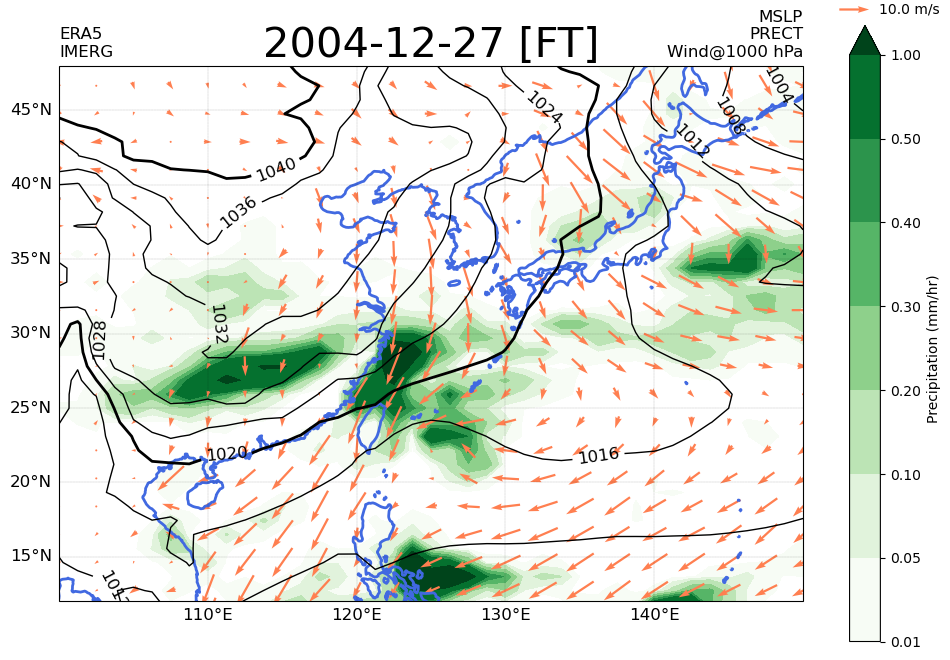

In [5]:
# plot weather map
#sequence plot
for doy in range(pd.to_datetime('2004-11-25').dayofyear,pd.to_datetime('2004-12-28').dayofyear):
    ds_plot=ds_yr.isel(time=doy-1)
    dateStr=pd.to_datetime(ds_plot.time.values).strftime('%Y-%m-%d')
    regime=df_weather[df_weather.date==dateStr].regime.values[0]
    if regime=='LCD':
        regime='WS'
    resample = ds_plot.isel(lon=slice(None, None, 2),lat=slice(None, None, 2))
    # Defining the figure
    plt.close()
    fig = plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

    # Axes with Cartopy projection
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    # and extent
    ax.set_extent([min_lon_plot, max_lon_plot, min_lat_plot, max_lat_plot], ccrs.PlateCarree())

    # Plotting using Matplotlib the mean current
    cs_p = ds_plot['precipitation'].plot.contourf(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.2,0.3,0.4,0.5,1.0],\
                                                  extend='max',cmap='Greens',transform=ccrs.PlateCarree(),\
                                                  cbar_kwargs=dict(label='Precipitation (mm/hr)'))
    cs = ds_plot['msl'].plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=slp_levels,
                      colors='k',
                      linewidths=slp_lws)
    q1=resample.plot.quiver(ax=ax,x='lon', y='lat', u='u', v='v', transform=ccrs.PlateCarree(),
                        scale=250,color='coral',width=0.003,add_guide=False)

    ax.clabel(cs, slp_levels, inline=True, fmt='%.0f', fontsize=12)
    #ax.clabel(cs_p2, [0.01,0.05,0.1,0.5,1.0], inline=True, fmt='%.2f', fontsize=12)
    #q1=ds_plot.plot.quiver(x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(), scale=80,color='g')
    ax.coastlines(resolution='50m',linewidth=2.0,color='royalblue')
    # Plot lat/lon grid 
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12} 

    #ax.plot([min_lon_tw, max_lon_tw,max_lon_tw,min_lon_tw,min_lon_tw],\
    #    [min_lat_tw,min_lat_tw, max_lat_tw,max_lat_tw,min_lat_tw],\
    #    lw=2.5,color='b',transform=ccrs.PlateCarree())
    #ax.plot([min_lon_ish, max_lon_ish,max_lon_ish,min_lon_ish,min_lon_ish],\
    #    [min_lat_ish,min_lat_ish, max_lat_ish,max_lat_ish,min_lat_ish],\
    #    lw=2.5,ls='--',color='r',transform=ccrs.PlateCarree())

    ax.set_title('%s [%s]'%(dateStr,regime),fontsize=30)
    ax.set_title('ERA5\nIMERG',fontsize=12,loc='left')
    ax.set_title('MSLP\nPRECT\nWind@1000 hPa',fontsize=12,loc='right')
    #ax.text(max_lon_tw+1,max_lat_tw-1.5,'prR=%.1f%%'%(prR*100),color='b',fontsize=15,transform=ccrs.PlateCarree())
    #ax.text(max_lon_tw+1,min_lat_tw+1,'WDCor=%.1f $\degree$'%wdCor,color='r',fontsize=15,transform=ccrs.PlateCarree())
    # Vector options declaration
    veclenght = 10
    maxstr = '%3.1f m/s' % veclenght
    plt.quiverkey(q1,0.8,0.9,veclenght,maxstr,labelpos='E', coordinates='figure').set_zorder(11)
    #plt.savefig('../figures/weatherMap_local.%s.ERA5.png'%r,dpi=200)
    print(doy,dateStr)
    plt.savefig('../figures/weatherMap.%d.yr%d.ERA5.png'%(doy,yr),dpi=200)